# Setup and Imports

In [ ]:
# Core
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerBase
import torch
import h5py
import lazy5
from lazy5.inspect import get_datasets, get_attrs_dset
from datetime import datetime

# Local modules
import dataset_utils
import plot_utils
import post_UNet_utils



# Reload during active development
importlib.reload(dataset_utils)
importlib.reload(post_UNet_utils)
importlib.reload(plot_utils)

# Common imports
from dataset_utils import voigt_peak



from plot_utils import (
    plot_voigt_fit_res,
    init_plot_context,
)

from tidytorch_utils import (
    process_conv_deriv_fit,
    pseudo_voigt,
    denoise_spectrum,
    compute_wavelet_peak,
    precompute_lorentz4_wavelets,

)

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("device:", device)



device: cuda


In [ ]:

import os


def load_h5_file(filename, galvo=True, data_path=None, nrb_path=None, dark_path=None):
    """Load BCARS hyperspectral data from an HDF5 file.

    Parameters
    ----------
    filename  : path to the .h5 file
    galvo     : unused flag kept for API compatibility
    data_path : explicit dataset path for data. If None, tries known paths then
                auto-detects the first 3-D dataset in the file.
    nrb_path  : explicit dataset path for NRB. If None, tries known paths then
                falls back to a vector of ones.
    dark_path : explicit dataset path for dark frame. If None, tries known paths
                then returns None if not found.

    Returns
    -------
    data, nrb, dark, attrs
      dark is None if no dark frame was found.
    """
    _DATA_CANDIDATES = [
        '/raw_data/hyperspectral_image_0000',
        '/preprocessed_images/medfilter_raw',
        '/preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG',
        '/preprocessed_images/ratio_SVD_KK_PhaseErrorCorrectALS',
        '/preprocessed_images/medfilter_ratio',
        '/preprocessed_images/ratio',
    ]
    _NRB_CANDIDATES = [
        '/preprocessed_images/medfilter_nrb_for_ratio',
        '/preprocessed_images/nrb',
        '/nrb',
    ]
    _DARK_CANDIDATES = [
        '/raw_data/dark_image_pre',
        '/raw_data/dark_image_post',
        '/raw_data/dark',
        '/dark',
    ]

    data, nrb, dark, attrs = None, None, None, None
    found_data_path = None

    with h5py.File(filename, "r") as f:
        all_datasets = get_datasets(f)
        print("Available datasets:", all_datasets)

        # ── Data ──────────────────────────────────────────────────────────────
        if data_path is not None:
            if data_path not in f:
                raise KeyError(
                    f"data_path '{data_path}' not found.\n"
                    f"Available datasets: {all_datasets}"
                )
            found_data_path = data_path
        else:
            for path in _DATA_CANDIDATES:
                if path in f:
                    found_data_path = path
                    break

            if found_data_path is None:
                # Auto-detect: pick the first dataset with 3+ dimensions
                for path in all_datasets:
                    if path in f and len(f[path].shape) >= 3:
                        found_data_path = path
                        print(f"Auto-detected data at: {path} — pass data_path='{path}' to suppress this message")
                        break

            if found_data_path is None:
                raise KeyError(
                    "Could not find a suitable data dataset.\n"
                    f"Available datasets: {all_datasets}\n"
                    "Pass data_path= to specify one explicitly."
                )

        data = np.array(f[found_data_path])
        print(f"Data   loaded from: {found_data_path}  shape: {data.shape}")

        # ── NRB ───────────────────────────────────────────────────────────────
        found_nrb_path = nrb_path
        if found_nrb_path is not None:
            if found_nrb_path not in f:
                raise KeyError(
                    f"nrb_path '{found_nrb_path}' not found.\n"
                    f"Available datasets: {all_datasets}"
                )
        else:
            for path in _NRB_CANDIDATES:
                if path in f:
                    found_nrb_path = path
                    break

        if found_nrb_path is not None:
            nrb = np.array(f[found_nrb_path])
            print(f"NRB    loaded from: {found_nrb_path}  shape: {nrb.shape}")
        else:
            nrb = np.ones(data.shape[-1])
            print(f"NRB not found — using ones  shape: {nrb.shape}")

        # ── Dark ──────────────────────────────────────────────────────────────
        found_dark_path = dark_path
        if found_dark_path is not None:
            if found_dark_path not in f:
                raise KeyError(
                    f"dark_path '{found_dark_path}' not found.\n"
                    f"Available datasets: {all_datasets}"
                )
        else:
            for path in _DARK_CANDIDATES:
                if path in f:
                    found_dark_path = path
                    break

        if found_dark_path is not None:
            dark = np.array(f[found_dark_path])
            print(f"Dark   loaded from: {found_dark_path}  shape: {dark.shape}")
        else:
            print("Dark not found — dark=None")

        # ── Attributes ────────────────────────────────────────────────────────
        attrs = get_attrs_dset(filename, found_data_path)
        print(f"Attrs  loaded from: {found_data_path}")

    return data, nrb, dark, attrs


import os
import numpy as np

def save_h5_file(
    filename,
    SAVE_FOLDER,
    attrs=None,
    data=None,
    original=None,
    nrb=None,
    dark=None,
    model=None,
    peak_params=None,
    x_axis=None,
):
    """
    Save BCARS fit results to an HDF5 file using lazy5.

    Parameters
    ----------
    filename : str
        Base filename for the output HDF5 file.
    SAVE_FOLDER : str
        Folder where the file will be saved.
    attrs : dict, optional
        Attribute dictionary to write to saved datasets.
    data : array-like, optional
        Raw/original data cube. If None, `original` will be used.
    original : array-like, optional
        Alternative name for raw/original data, matching np.savez usage.
    nrb : array-like, optional
        NRB dataset.
    dark : array-like, optional
        Dark dataset.
    model : array-like, optional
        Fitted model data.
    peak_params : array-like, optional
        Peak parameter array.
    x_axis : array-like, optional
        Spectral axis / x-axis values.
    """

    if attrs is None:
        attrs = {}

    # Let `original` behave like the raw data input from np.savez_compressed
    raw_data = data if data is not None else original

    out_file = f"fitted_{filename}"
    fid = os.path.join(SAVE_FOLDER, out_file)

    first_write = True

    def _save_dataset(dset_name, arr, dtype=None):
        nonlocal first_write
        if arr is None:
            return

        arr_np = np.asarray(arr, dtype=dtype) if dtype is not None else np.asarray(arr)

        lazy5.create.save(
            file=out_file,
            pth=SAVE_FOLDER,
            dset=dset_name,
            data=arr_np,
            mode='w' if first_write else 'a'
        )
        first_write = False

        if attrs:
            lazy5.alter.write_attr_dict(dset=dset_name, attr_dict=attrs, fid=fid)

    # Save datasets
    _save_dataset('preprocessed_images/raw', raw_data, dtype=np.uint16)
    _save_dataset('preprocessed_images/nrb', nrb, dtype=np.uint16)
    _save_dataset('preprocessed_images/dark', dark, dtype=np.uint16)
    _save_dataset('preprocessed_images/model', model, dtype=np.float32)
    _save_dataset('preprocessed_images/peak_params', peak_params)   # keep native dtype unless you want otherwise
    _save_dataset('preprocessed_images/x_axis', x_axis, dtype=np.float32)



# Load Spectrum of Interest

In [3]:
print(get_datasets("/home/adiering3/projects/Raman-Spectral-Analysis/preprocessed_medfilter_replaced_myo3_polyme_35mWSC45mWProber_202602090655_PROCESS_202632_11_57_2_850702.h5"))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/adiering3/projects/Raman-Spectral-Analysis/preprocessed_medfilter_replaced_myo3_polyme_35mWSC45mWProber_202602090655_PROCESS_202632_11_57_2_850702.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
now = datetime.now().strftime("%m%d%Y_%H:%M:%S")
print(now)

03122026_13:23:20


In [4]:
now = datetime.now().strftime("%m%d%Y_%H:%M:%S")

RAW_PATH = "/home/adiering3/projects/ChiR2026/Test_experimental_data/Chen celegans/preprocessed_medfilter_dhsgfp_20250502_0624pm_06_PROCESS_202555_14_21_42_848569.h5"
raw_data, nrb, dark, attrs = load_h5_file(RAW_PATH)
# data, nrb, dark, attrs = load_h5_file("/home/adiering3/projects/Hvetch_ScaleMap/preprocessed_medfilter_hvetch_nodule_3a_05152025_02_PROCESS_20251210_13_21_4_384624.h5")
file = "replaced_myo3_p0lyme"
filename = os.path.join("{file}_{now}")
print(f"filename = {filename}")
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe



Available datasets: ['/preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG']
Data   loaded from: /preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG  shape: (300, 500, 2304)
NRB not found — using ones  shape: (2304,)
Dark not found — dark=None
Attrs  loaded from: /preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG
filename = {file}_{now}


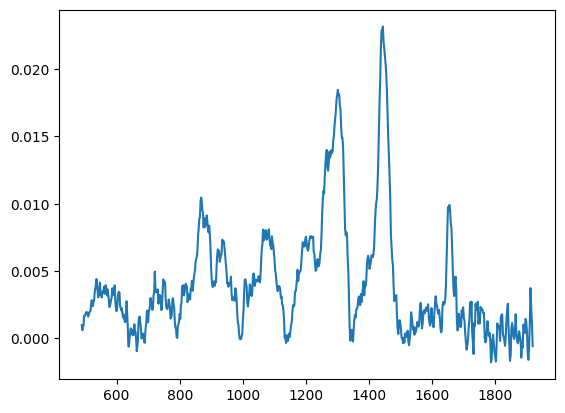

In [5]:
crop_start = 550
crop_end = 1250
crop_wn= wn[crop_start:crop_end] ## Crop the wavenumber axis to match the data
wavenumbers= crop_wn

data = raw_data[:, :, crop_start:crop_end]
# plt.plot(np.imag(raw_data[0,0,:]))
plt.plot(wavenumbers,np.imag(data[200,300,:]))

In [6]:
print(data.shape)

(300, 500, 700)


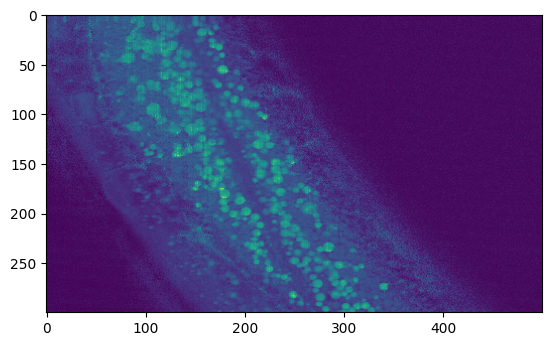

In [7]:
plt.imshow(np.imag(data[:,:,400]))
# plt.imshow(np.imag(data[:,:,400]))

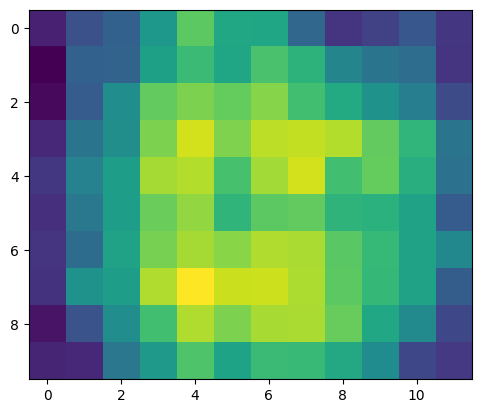

In [16]:
plt.imshow(np.imag(data[155:165,210:222,400]))

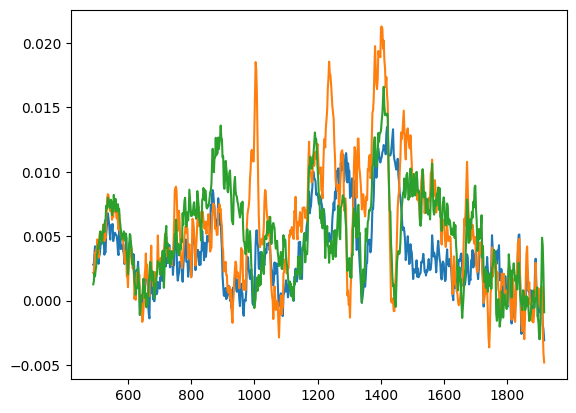

In [9]:
plt.plot(wavenumbers, np.imag(data[160,297,:]))
plt.plot(wavenumbers, np.imag(data[162,297,:]))
plt.plot(wavenumbers, np.imag(data[164,299,:]))

# Fitting Parameters and Pre-computes

In [17]:
pixx= 155
pixy= 210
spectrum = np.imag(data[pixx, pixy, :])

x = wavenumbers.copy()
x = x.astype(np.float32)

widths = np.linspace(1, 10, 100)

sigmas = torch.as_tensor(widths, dtype=torch.float32)
gammas = torch.tensor([5.0], dtype=torch.float32)
x_gpu  = torch.as_tensor(x, dtype=torch.float32)

x_c  = x_gpu - x_gpu.mean()

sigs = sigmas.view(-1, 1, 1)
gams = gammas.view( 1,-1, 1)
x_bc = x_c.view(   1, 1,-1)

profiles = pseudo_voigt(x_bc, sigs, gams)
max_vals = profiles.amax(dim=-1, keepdim=True)
wavelet_peaks_cached = profiles / (max_vals + 1e-12) 
wavelet_peaks_cached = wavelet_peaks_cached.to(device)

# ── Precomputed constants (shared across all sweep calls) ─────────────────────
_x_dev     = x_gpu.to(device)
_lor4_bank = precompute_lorentz4_wavelets(sigmas.to(device), _x_dev)  # (n_widths, n_pts)

_sigma_t = torch.tensor(3.0,  dtype=torch.float32, device=device)
_gamma_t = torch.tensor(1e-6, dtype=torch.float32, device=device)
_kernel  = compute_wavelet_peak(_sigma_t, _gamma_t, _x_dev)
_kernel  = _kernel / _kernel.sum()
_ker_fft = torch.fft.fft(torch.fft.ifftshift(_kernel))  # (n_pts,)

# Param bounds tensors (reused each step)
_LO = torch.tensor([0.0,    0.0, 0.05, 0.05], device=device)
_HI = torch.tensor([1.0, 4000.0, 50.0, 50.0], device=device)

print(f"Wavelet bank : {_lor4_bank.shape}  on {_lor4_bank.device}")
print(f"Denoise kern : {_ker_fft.shape}    on {_ker_fft.device}")



Wavelet bank : torch.Size([100, 700])  on cuda:0
Denoise kern : torch.Size([700])    on cuda:0


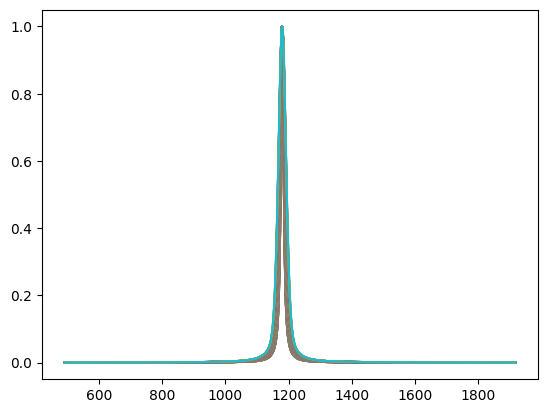

In [18]:

for i in range(100):
    plt.plot(x, wavelet_peaks_cached[i,0,:].cpu().numpy())

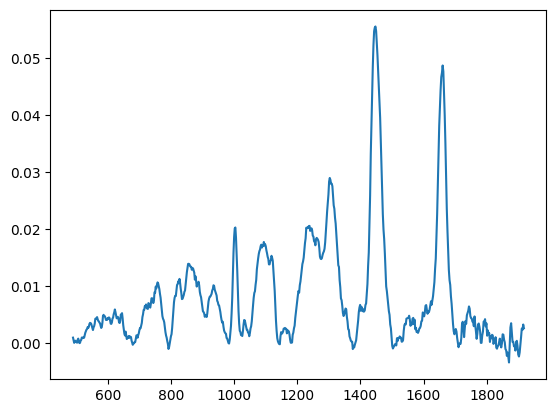

In [19]:
plt.plot(wavenumbers, spectrum)

# Quick Convolution Denoise

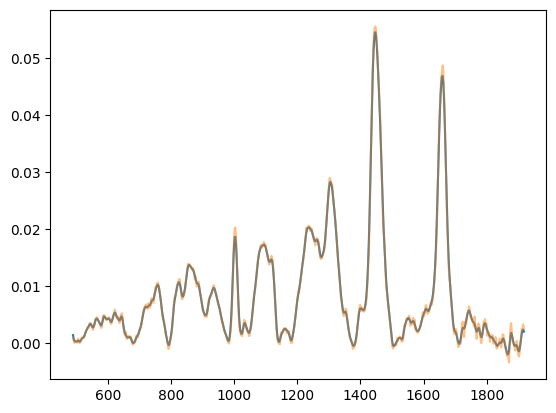

In [20]:
spectrum_denoised = denoise_spectrum(
    torch.as_tensor(spectrum, dtype=torch.float32),
    x_gpu,
    sigma=3.0,   # wavenumber units — start at ~half your narrowest peak width
    gamma=0.0,   # pure Gaussian → minimal ringing
)
plt.plot(x, spectrum_denoised.numpy(), label='Denoised Spectrum')
plt.plot(x, spectrum, alpha=0.5, label='Original Spectrum')


# Run the Fitting for one Pixel

In [21]:
params_cd, converged_cd, n_iter_cd, response_tensor_cd, peak_mask_cd, p0_cd = process_conv_deriv_fit(
    spectrum_denoised +0.0005,
    x,
    sigmas=sigmas,
    gammas=gammas,
    wavelet_peaks=wavelet_peaks_cached,
    response_threshold=0.001,
    amp_threshold = 1e-6,
    min_scale_votes=1,
    min_spacing=7.0,
    max_peaks=200,
    max_iter=4000,
    tol=1e-5,
    convolution='Lor4',
    scale_preference_fraction=0.8,
)

print(f"converged: {converged_cd}  n_iter: {n_iter_cd}")
print(f"peaks detected (mask): {peak_mask_cd.sum().item()}")
print(f"non-zero fitted peaks: {(params_cd.reshape(-1,4)[:,0] > 1e-3).sum().item()}")


converged: False  n_iter: 4000
peaks detected (mask): 70
non-zero fitted peaks: 32


y_peaks shape: (42, 700)
RMSE: 0.0059   R²: 0.6263


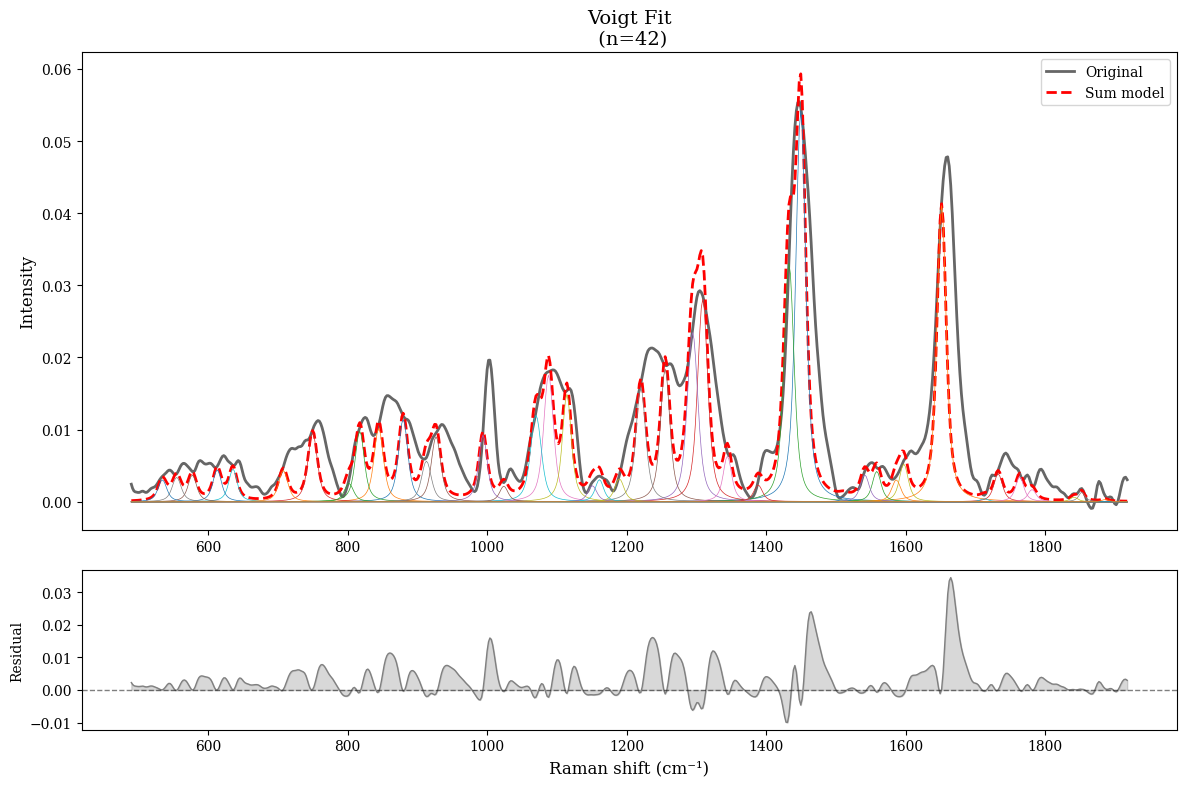

In [22]:
plot_voigt_fit_res(x, spectrum_denoised+0.001, p0_cd, title="Conv-Deriv Fit Results")

y_peaks shape: (32, 700)
RMSE: 0.0010   R²: 0.9887


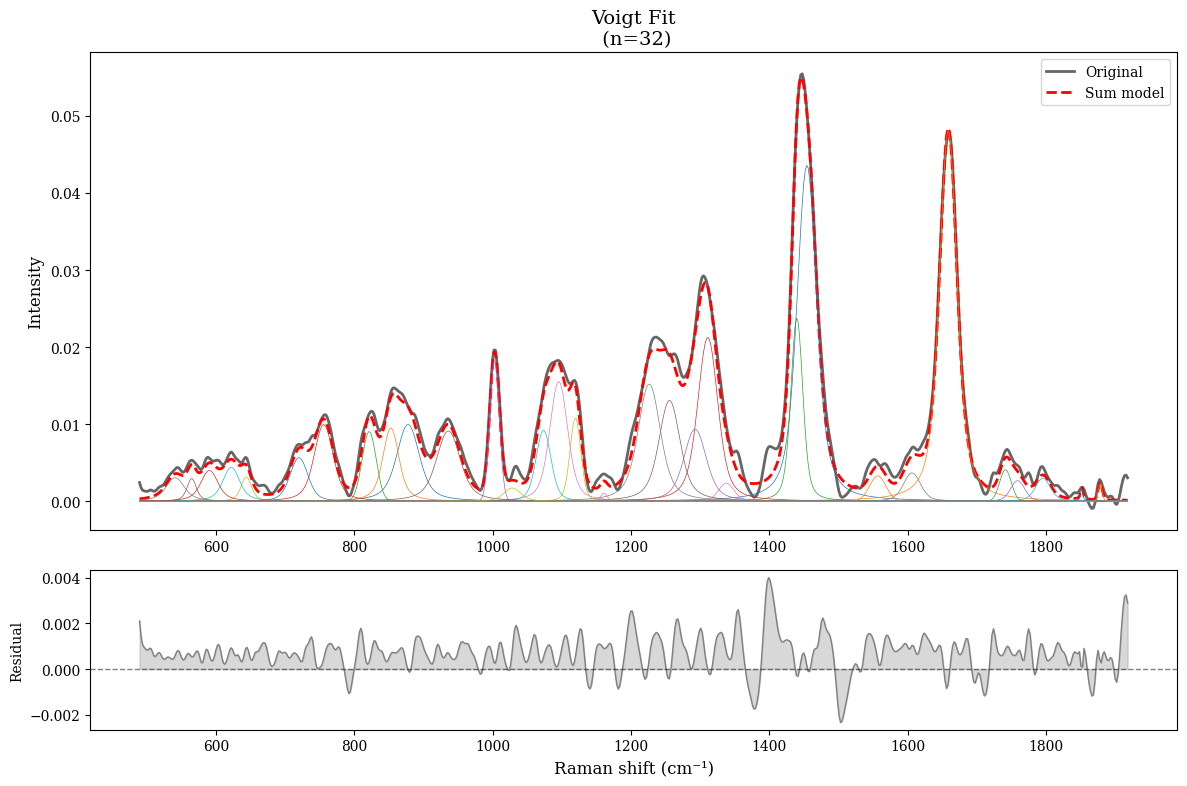

In [23]:
plot_voigt_fit_res(x, spectrum_denoised+0.001, params_cd, title="Conv-Deriv Fit Results")

# Run the Fitting for a batch

Sweep context initialised on cuda
  Wavelet bank : torch.Size([100, 700])
  Denoise kern : torch.Size([700])
ROI shape: (10, 12, 700)  ->  batch spectra: 120 × 700
[init] 120/120 (100.0%) | 0.3s elapsed | ETA 0.0s
[fit[1/1]] iter 250/5000 (5.0%) | loss/pix=1.0326e-02 | lr=9.99e-03 | elapsed 3.5s | ETA 66.0s
[fit[1/1]] iter 500/5000 (10.0%) | loss/pix=6.0158e-03 | lr=9.89e-03 | elapsed 6.5s | ETA 58.4s
[fit[1/1]] iter 750/5000 (15.0%) | loss/pix=3.6395e-03 | lr=9.66e-03 | elapsed 9.4s | ETA 53.2s
[fit[1/1]] iter 1000/5000 (20.0%) | loss/pix=2.3159e-03 | lr=9.31e-03 | elapsed 12.3s | ETA 49.3s
[fit[1/1]] iter 1250/5000 (25.0%) | loss/pix=1.5999e-03 | lr=8.84e-03 | elapsed 15.8s | ETA 47.5s
[fit[1/1]] iter 1500/5000 (30.0%) | loss/pix=1.2115e-03 | lr=8.27e-03 | elapsed 19.7s | ETA 46.1s
[fit[1/1]] iter 1750/5000 (35.0%) | loss/pix=9.8968e-04 | lr=7.61e-03 | elapsed 23.5s | ETA 43.7s

Batch fit summary:
  total time : 24.046s  ->  0.2004s per pixel
  fit-only   : 23.560s  ->  0.1963s per p

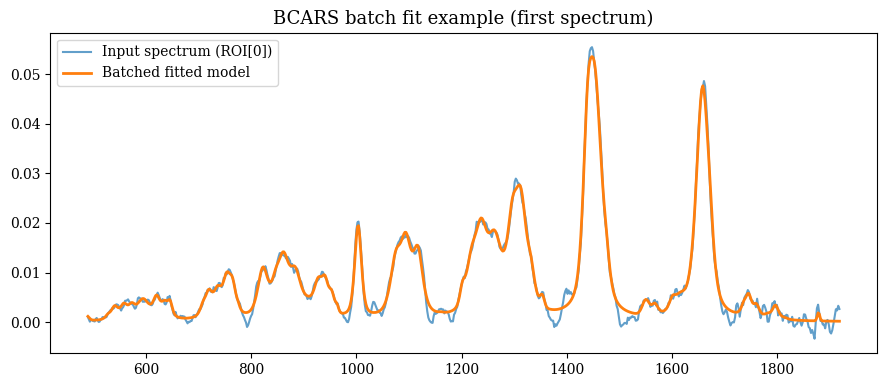

In [24]:
# ── Batch fit directly on loaded BCARS cube (no RamanDataset) ───────────────────
import time
import numpy as np
import torch
import tidytorch_utils as ttu

# Make sure sweep context exists for tidytorch_utils internals
ttu.init_sweep_context(x_gpu, sigmas, gammas, device, widths)
init_plot_context(x, widths)

# Select a region from your already-loaded cube
X0, X1 = 155, 165
Y0, Y1 = 210, 222

# Build (B, n_pts) batch from existing data variable
cube_roi = np.asarray(data[X0:X1, Y0:Y1, :])
if np.iscomplexobj(cube_roi):
    cube_roi = np.imag(cube_roi)
spectra_np = cube_roi.reshape(-1, cube_roi.shape[-1]).astype(np.float32)
B = spectra_np.shape[0]
print(f"ROI shape: {cube_roi.shape}  ->  batch spectra: {B} × {spectra_np.shape[1]}")

spectra_gpu = torch.as_tensor(spectra_np, dtype=torch.float32, device=ttu._ctx_device)

# ── Fit controls ──────────────────────────────────────────────────────────────
MAX_ITER_BATCH = 5000
TOL_BATCH = 1e-3
AMP_THR_BATCH = 1e-4
MIN_SPACING_BATCH = 5.0
MAX_PEAKS_BATCH = 200
RESPONSE_THRESHOLD = 1e-5
MIN_SCALE_VOTES = 5

# Chunk size for transform+vote pass — (CHUNK, n_widths, n_pts) × 8 bytes
# CHUNK=500 → ~280 MB; raise if you have more VRAM.
TRANSFORM_CHUNK = 500

# Chunk size for Adam optimiser — (CHUNK, max_peaks, n_pts) × 4 bytes
# CHUNK=2000 at max_peaks~92 → ~514 MB; lower if still OOM.
FIT_CHUNK = 2000

# Progress checkpoint cadences
CHECKPOINT_EVERY = 1000
FIT_CHECKPOINT_EVERY = 250

# Aggressive-start controls
AGGR_STEPS = 80
AGGR_LR_MULT = 4.0
AGGR_CLIP = 3.0
AGGR_BETA1 = 0.85

def _sync_dev(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()
    elif dev.type == "mps":
        torch.mps.synchronize()

# Warmup
with torch.no_grad():
    _ = ttu._denoise_batch(spectra_gpu[:1])

_sync_dev(ttu._ctx_device)
t0 = time.perf_counter()

# ── 1) Denoise — (B, n_pts), small enough to keep on GPU ─────────────────────
spec_d = ttu._denoise_batch(spectra_gpu)

# ── 2) Chunked transform + vote — never materialise (B, n_widths, n_pts) ─────
n_pts_val = spec_d.shape[1]
vote_count = torch.zeros(B, n_pts_val, dtype=torch.long,    device=ttu._ctx_device)
max_resp   = torch.zeros(B, n_pts_val, dtype=torch.float32, device=ttu._ctx_device)
n_widths   = None

for c_start in range(0, B, TRANSFORM_CHUNK):
    c_end  = min(c_start + TRANSFORM_CHUNK, B)
    resp_c = ttu._lor4_transform_batch(spec_d[c_start:c_end])  # (C, n_widths, n_pts)
    C, nw, np_ = resp_c.shape
    if n_widths is None:
        n_widths = nw
    flat_masks_c = ttu.find_peaks_derivative_mask_batch(
        ttu._x_dev, resp_c.reshape(C * nw, np_), min_height=0.0
    )
    masks_c = flat_masks_c.reshape(C, nw, np_)
    vote_count[c_start:c_end] = masks_c.long().sum(dim=1)
    max_resp[c_start:c_end]   = resp_c.max(dim=1).values
    del resp_c, flat_masks_c, masks_c
    if ttu._ctx_device.type == "cuda":
        torch.cuda.empty_cache()

peak_masks = (vote_count >= MIN_SCALE_VOTES) & (max_resp > RESPONSE_THRESHOLD)

# ── 3) Build padded p0 — recompute resp[i] per spectrum (~560 KB each) ────────
npq_max = MAX_PEAKS_BATCH * 4
p0_flat_list = []
n_real_peaks = []

t_init0 = time.perf_counter()
for i in range(B):
    resp_i = ttu._lor4_transform_batch(spec_d[i:i+1]).squeeze(0)  # (n_widths, n_pts)
    p0 = ttu.build_initial_guesses_from_derivative_mask(
        resp_i.unsqueeze(1),
        ttu._ctx_sigmas.to(ttu._ctx_device),
        ttu._ctx_gammas[:1].to(ttu._ctx_device),
        ttu._x_dev,
        spec_d[i],
        peak_masks[i],
        max_peaks=MAX_PEAKS_BATCH,
        min_spacing=MIN_SPACING_BATCH,
        scale_preference_fraction=0.008,
    )
    del resp_i
    p0_flat = p0[:npq_max]
    p0_flat_list.append(p0_flat)
    n_peaks_i = int((p0_flat[0::4] > 0).sum().item())
    n_real_peaks.append(min(n_peaks_i, MAX_PEAKS_BATCH))

    done = i + 1
    if (done % CHECKPOINT_EVERY == 0) or (done == B):
        elapsed = time.perf_counter() - t_init0
        px_per_sec = done / max(elapsed, 1e-9)
        eta = (B - done) / max(px_per_sec, 1e-9)
        print(f"[init] {done}/{B} ({100.*done/B:.1f}%) | {elapsed:.1f}s elapsed | ETA {eta:.1f}s")

max_real = max(1, max(n_real_peaks) if n_real_peaks else 1)
npq = max_real * 4
p0_batch = torch.zeros(B, npq, device=ttu._ctx_device)
grad_mask = torch.zeros(B, npq, dtype=torch.float32, device=ttu._ctx_device)

for i, (p0_flat, n_peaks_i) in enumerate(zip(p0_flat_list, n_real_peaks)):
    n_take = min(p0_flat.numel(), npq)
    p0_batch[i, :n_take] = p0_flat[:n_take]
    grad_mask[i, :n_peaks_i * 4] = 1.0

# ── 4) Chunked Adam fit — (FIT_CHUNK, max_peaks, n_pts) at a time ─────────────
_sync_dev(ttu._ctx_device)
t_fit0 = time.perf_counter()

params_chunks = []
n_fit_chunks = (B + FIT_CHUNK - 1) // FIT_CHUNK
for fb_i, fb_start in enumerate(range(0, B, FIT_CHUNK)):
    fb_end = min(fb_start + FIT_CHUNK, B)
    chunk_params = ttu._fit_batch_adam(
        spec_d[fb_start:fb_end], ttu._x_dev,
        p0_batch[fb_start:fb_end], grad_mask[fb_start:fb_end],
        max_iter=MAX_ITER_BATCH,
        tol=TOL_BATCH,
        aggressive_start_steps=AGGR_STEPS,
        aggressive_lr_mult=AGGR_LR_MULT,
        aggressive_clip_norm=AGGR_CLIP,
        aggressive_beta1=AGGR_BETA1,
        progress_every=FIT_CHECKPOINT_EVERY,
        progress_prefix=f"fit[{fb_i+1}/{n_fit_chunks}]",
    )
    params_chunks.append(chunk_params.detach().cpu())
    del chunk_params
    if ttu._ctx_device.type == "cuda":
        torch.cuda.empty_cache()

_sync_dev(ttu._ctx_device)
fit_only_sec = time.perf_counter() - t_fit0

params_batch = torch.cat(params_chunks, dim=0).to(ttu._ctx_device)

# ── 5) Post-process ───────────────────────────────────────────────────────────
params_batch = ttu._prune_peaks_batch(params_batch, amp_threshold=AMP_THR_BATCH)
params_batch = ttu._deduplicate_peaks_batch(params_batch, MIN_SPACING_BATCH)

_sync_dev(ttu._ctx_device)
total_sec = time.perf_counter() - t0

n_fit_peaks = (params_batch.reshape(B, -1, 4)[:, :, 0] > AMP_THR_BATCH).sum(dim=1)
print("\nBatch fit summary:")
print(f"  total time : {total_sec:.3f}s  ->  {total_sec/B:.4f}s per pixel")
print(f"  fit-only   : {fit_only_sec:.3f}s  ->  {fit_only_sec/B:.4f}s per pixel")
print(f"  fitted peaks/pixel: mean={n_fit_peaks.float().mean().item():.1f}  median={n_fit_peaks.float().median().item():.1f}")

# Reconstruct model for first ROI spectrum
model0 = ttu._compute_model_batch(params_batch[:1], ttu._x_dev).squeeze(0).detach().cpu().numpy()
spec0 = spectra_np[0]
plt.figure(figsize=(9,4))
plt.plot(x, spec0, label='Input spectrum (ROI[0])', alpha=0.7)
plt.plot(x, model0, label='Batched fitted model', lw=2)
plt.title('BCARS batch fit example (first spectrum)')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
filename = "lipid_droplet_fitted_20260326"
save_h5_file(
    filename,
    SAVE_FOLDER="/home/adiering3/projects/ChiR2026/Test_experimental_data",
    attrs=attrs,
    data=raw_data,
    nrb=nrb,
    dark=dark,
    model=model0,  # You can save the full batch if desired, but here we save just the first spectrum's model for demonstration
    peak_params=params_batch.cpu().numpy(),
    x_axis=x.astype(np.float32),
)

/tmp/ipykernel_8950/1534364625.py:188: ComplexWarning: Casting complex values to real discards the imaginary part
  arr_np = np.asarray(arr, dtype=dtype) if dtype is not None else np.asarray(arr)


peak_params_roi shape: (330, 120, 396)  (x=330, y=120, params=396)
model_roi shape: (330, 120, 700)


/tmp/ipykernel_1517/1534364625.py:188: ComplexWarning: Casting complex values to real discards the imaginary part
  arr_np = np.asarray(arr, dtype=dtype) if dtype is not None else np.asarray(arr)


Saved -> bcars_roi_batch_fit.npz


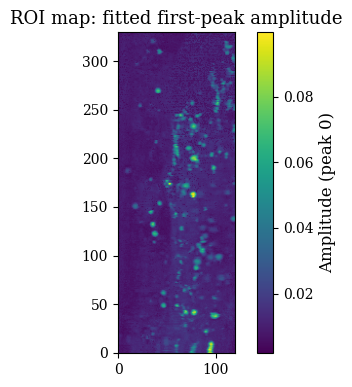

In [52]:
# ── Reshape batched params back to ROI-aligned cube and save ─────────────────────
params_np = params_batch.detach().cpu().numpy().astype(np.float32)   # (B, n_params)
roi_h = int(X1 - X0)
roi_w = int(Y1 - Y0)

if params_np.shape[0] != roi_h * roi_w:
    raise ValueError(
        f"Batch size mismatch: got {params_np.shape[0]} spectra, expected {roi_h*roi_w} from ROI shape."
    )

peak_params_roi = params_np.reshape(roi_h, roi_w, -1)
print(f"peak_params_roi shape: {peak_params_roi.shape}  (x={roi_h}, y={roi_w}, params={peak_params_roi.shape[-1]})")

# Compute model cube in chunks — _compute_model_batch(full_batch) would OOM
MODEL_CHUNK = FIT_CHUNK  # reuse the same safe chunk size
model_chunks = []
with torch.no_grad():
    for mc_start in range(0, B, MODEL_CHUNK):
        mc_end = min(mc_start + MODEL_CHUNK, B)
        mc = ttu._compute_model_batch(
            params_batch[mc_start:mc_end], ttu._x_dev
        ).cpu().numpy().astype(np.float32)
        model_chunks.append(mc)
model_batch_np = np.concatenate(model_chunks, axis=0)
model_roi = model_batch_np.reshape(roi_h, roi_w, -1)
print(f"model_roi shape: {model_roi.shape}")

save_h5_file(
    "replaced_myo3_p0lyme_roi_batch_fit",
    SAVE_FOLDER="/home/adiering3/projects/Raman-Spectral-Analysis",
    attrs=attrs,
    data=raw_data,
    nrb=nrb,
    dark=dark,
    model=model_roi,  # Save the full model cube for the ROI
    peak_params=peak_params_roi,  # Save the peak parameters cube for the ROI
    x_axis=x.astype(np.float32),
)

# np.savez_compressed(
#     "bcars_roi_batch_fit.npz",
#     peak_params=peak_params_roi,
#     model=model_roi,
#     x_axis=np.asarray(x, dtype=np.float32),
#     original=data[X0:X1, Y0:Y1, :]
# )
print("Saved -> bcars_roi_batch_fit.npz")

amp0_map = peak_params_roi[:, :, 0]
plt.figure(figsize=(5,4))
plt.imshow(amp0_map, origin='lower', cmap='viridis')
plt.colorbar(label='Amplitude (peak 0)')
plt.title('ROI map: fitted first-peak amplitude')
plt.tight_layout()
plt.show()

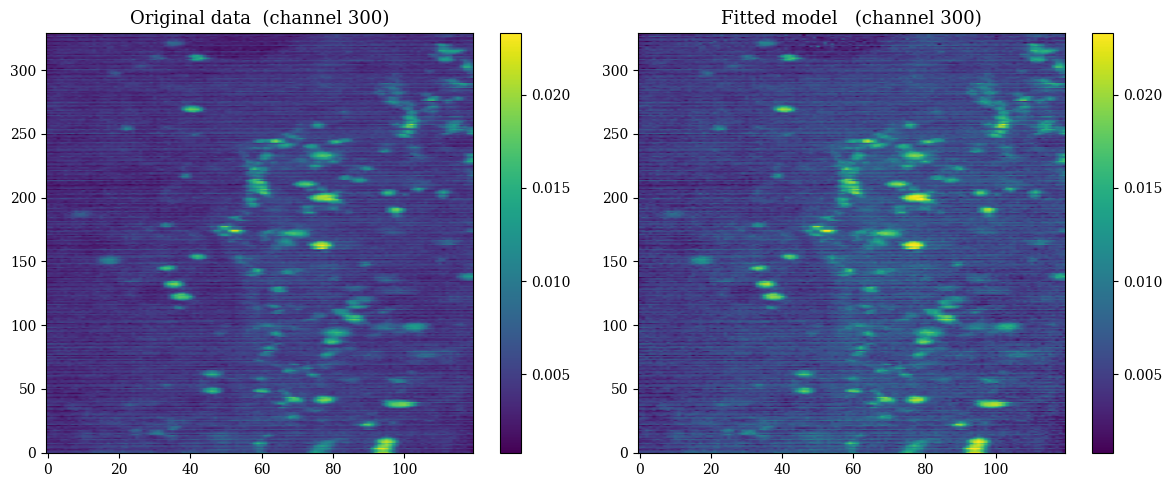

In [51]:
SPEC_IDX = 300  # spectral index to display — change to any channel of interest

orig_slice  = np.imag(data[X0:X1, Y0:Y1, SPEC_IDX])
model_slice = model_roi[:, :, SPEC_IDX]

vmin = orig_slice.min()
vmax = orig_slice.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(orig_slice,  origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title(f'Original data  (channel {SPEC_IDX})')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(model_slice, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title(f'Fitted model   (channel {SPEC_IDX})')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

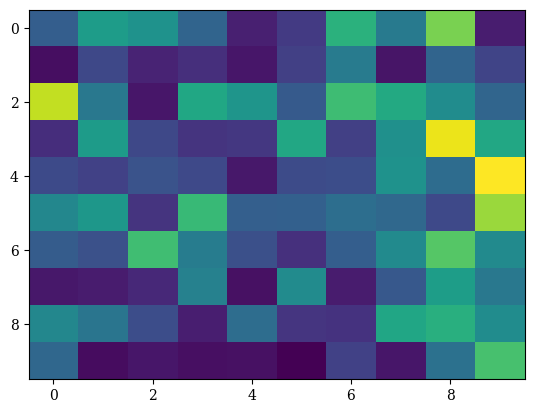

In [41]:
stuff = np.load("bcars_roi_batch_fit.npz")
orig = stuff['original']
mods = stuff['model']
# plt.plot(x, np.imag(orig[0,0,:]), label='Original Spectrum')
# plt.plot(x, (mods[0,0,:])    , label='Fitted Model')
plt.imshow(np.imag(orig[:,:, 350]), aspect='auto')
# plt.imshow(mods[:,:,350], aspect='auto')

In [ ]:
plt

# Convert peak parameters to model fit

In [154]:
        
def model_sum(params, x):
    def _np(a):
        if isinstance(a, torch.Tensor):
            return a.detach().cpu().numpy()
        return np.asarray(a)

    x      = _np(x)
    params = _np(params)

    n_peaks = len(params) // 4
    p = params[:n_peaks * 4].reshape(-1, 4)  # reshape (N, 4): amp, ctr, sigma, gam

    y_peaks = []
    for amp, ctr, sigma, gamma in p:
        if amp > 0:
            y_peaks.append(voigt_peak(x, ctr, amp, sigma, gamma))

    y_peaks = np.array(y_peaks)
    model_sum = y_peaks.sum(axis=0)
    return model_sum
    

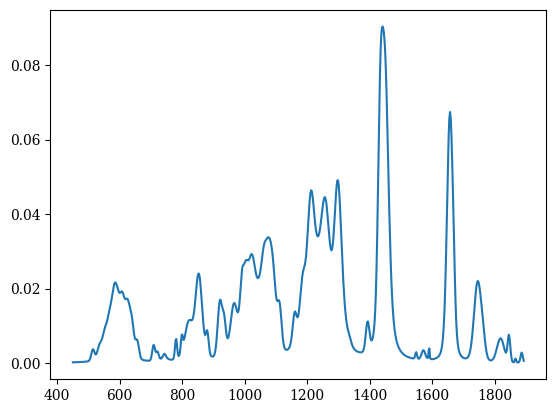

In [156]:
model_fit = model_sum(params_cd, x_gpu)
plt.plot(x, model_fit, label='Fitted Model')


In [158]:
np.savez("model_fit.npz", model_fit = model_fit)